<table class="table table-bordered">
    <tr>
     <th style="text-align:center;"><h3>IS217 - Case Study</h3><h3>Bank Account Profiling using Clustering (Practice)</h3></th>
    </tr>
</table>

The Dataset profile.csv contains information about bank customers. 
The descriptions of the columns are as follow:

    1. ID: Unique identifier
    2. CNT_TBM: Traditional bank methods transactions count
    3. CNT_ATM: ATM transaction count
    4. CNT_POS: Point-of-sale transaction count
    5. CNT_CSS: Customer service transaction count
    6. CNT_TOT: Total transaction count

In this practice, you are to:

    1. Perform EDA steps to understand the dataset better
    2. Perform data preparation steps as appropriate before clustering
    3. Generate an elbow curve and choose value of K 
    4. Perform k-means clustering (using K=5)
    5. Analyse the clustering solution and profile the clusters 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the data

In [2]:
profile = pd.read_csv('bankprofile.csv')

In [3]:
profile.head()

,ID,CNT_TBM,CNT_ATM,CNT_POS,CNT_CSC,CNT_TOT
0,41360,34,3,3,9,49
1,52094,44,17,5,18,84
2,57340,122,26,32,36,216
3,76885,42,3,6,1,52
4,89150,20,15,2,2,39


## 1. Perform EDA steps

### Check the DataFrame columns, any null values

In [4]:
profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   ID       100000 non-null  int64
 1   CNT_TBM  100000 non-null  int64
 2   CNT_ATM  100000 non-null  int64
 3   CNT_POS  100000 non-null  int64
 4   CNT_CSC  100000 non-null  int64
 5   CNT_TOT  100000 non-null  int64
dtypes: int64(6)
memory usage: 4.6 MB


In [5]:
profile.isnull().sum()

ID         0
CNT_TBM    0
CNT_ATM    0
CNT_POS    0
CNT_CSC    0
CNT_TOT    0
dtype: int64

### Summary Statistics

In [6]:
profile.describe()

,ID,CNT_TBM,CNT_ATM,CNT_POS,CNT_CSC,CNT_TOT
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,4.382146e+08,68.136960,19.499710,11.923300,6.684110,106.244080
std,2.526130e+08,101.154157,20.856101,20.733837,12.128559,113.370371
min,4.136000e+04,10.000000,3.000000,2.000000,1.000000,17.000000
25%,2.194891e+08,24.000000,3.000000,2.000000,1.000000,45.000000
50%,4.390647e+08,52.000000,13.000000,2.000000,2.000000,89.000000
75%,6.567857e+08,90.000000,29.000000,12.000000,7.000000,143.000000
max,8.756745e+08,14934.000000,628.000000,345.000000,607.000000,15225.000000


### Plot histogram for the variables

Note: You only need to plot for columns 'CNT_TBM','CNT_ATM', 'CNT_POS','CNT_CSC', 'CNT_TOT'.

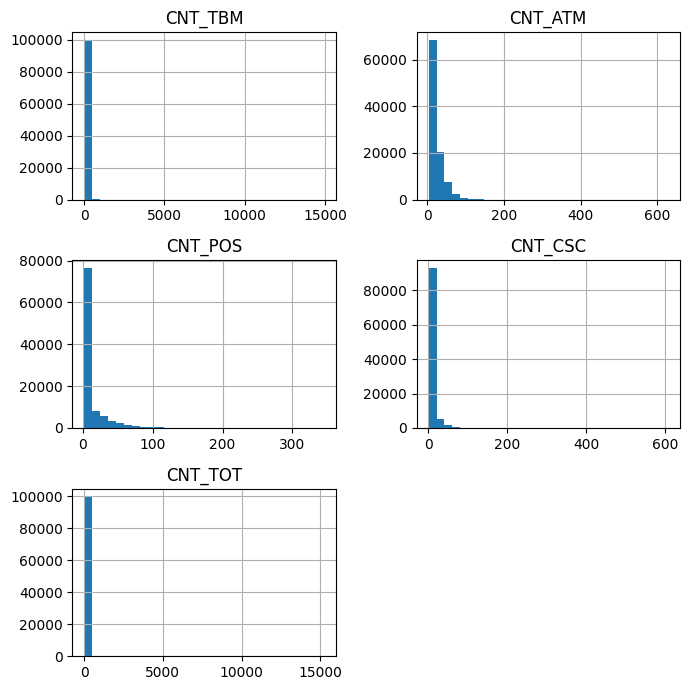

In [7]:
profile.hist(column = ['CNT_TBM','CNT_ATM', 'CNT_POS','CNT_CSC', 'CNT_TOT'], bins=30, figsize = (7,7))
plt.tight_layout()

## 2. Perform EDA Preparation Steps

If you have done the above correctly, you would have noticed that `CNT_TOT` is the sum of the counts across various categories. Including it in the clustering model along with the individual category counts would give undue weight to its effect, as it combines information already represented by those variables. Therefore, we will exclude `CNT_TOT` from our clustering model. 

The remaining 4 variables `CNT_ATM`, `CNT_POS`, `CNT_CSC` and `CNT_TBM` are highly right-skewed. It will be difficult to develop meaningful segments from such highly skewed inputs. This finding indicates the need for data transformations.

### Transform using Logarithm
Let's try taking logarithms on CNT_ATM, CNT_POS, CNT_CSC, CNT_TBM.

In [8]:
profile_2 = profile.iloc[:, 0:6]
profile_2['Log_CNT_ATM'] = np.log(profile_2['CNT_ATM'])
profile_2['Log_CNT_POS'] = np.log(profile_2['CNT_POS'])
profile_2['Log_CNT_CSC'] = np.log(profile_2['CNT_CSC'])
profile_2['Log_CNT_TBM'] = np.log(profile_2['CNT_TBM'])
profile_2.head()

C:\Users\Durga\AppData\Local\Temp\ipykernel_25212\4041733674.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile_2['Log_CNT_ATM'] = np.log(profile_2['CNT_ATM'])
C:\Users\Durga\AppData\Local\Temp\ipykernel_25212\4041733674.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile_2['Log_CNT_POS'] = np.log(profile_2['CNT_POS'])
C:\Users\Durga\AppData\Local\Temp\ipykernel_25212\4041733674.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

,ID,CNT_TBM,CNT_ATM,CNT_POS,CNT_CSC,CNT_TOT,Log_CNT_ATM,Log_CNT_POS,Log_CNT_CSC,Log_CNT_TBM
0,41360,34,3,3,9,49,1.098612,1.098612,2.197225,3.526361
1,52094,44,17,5,18,84,2.833213,1.609438,2.890372,3.784190
2,57340,122,26,32,36,216,3.258097,3.465736,3.583519,4.804021
3,76885,42,3,6,1,52,1.098612,1.791759,0.000000,3.737670
4,89150,20,15,2,2,39,2.708050,0.693147,0.693147,2.995732


In [10]:
profile_2.skew()

ID             -0.004286
CNT_TBM        53.052186
CNT_ATM         2.357293
CNT_POS         3.343805
CNT_CSC         6.236494
CNT_TOT        39.206104
Log_CNT_ATM     0.099795
Log_CNT_POS     1.058274
Log_CNT_CSC     0.785762
Log_CNT_TBM    -0.041798
dtype: float64

You would have noticed that taking the logarithm of these variables did not resolve the skewness issue. The distributions remain largely right-skewed.
We need to try other forms of transformation.

### Transform using Logit (Log of odds)

When analyzing consumer choices, using odds provides a better way to compare preferences across different banking methods. Odds, defined as the ratio of one choice relative to another, allows us to better understand the likelihood of consumers choosing one method over another.

We noticed that all the selected variables show highly skewed distributions. It will be difficult to develop meaningful segments from such highly skewed inputs. This requires a transformation of the raw data.

In Math, $odd = \frac{TransactionCount_{in\_category}}{TransactionCount_{out\_category}}$ 

In another words, odd refers to the probability of using the service (in category) over probability of <b>not</b> using the service (out of category).

In statistics, logit is the logarithm of the odds. It is also known as log-odds. Therefore, the logit function of the category is 

$logit_{category} = log(\frac{TransactionCount_{in\_category}}{TransactionCount_{out\_category}})$



Since odds range between 0 and 1 for probabilities below 50% and grow larger for higher probabilities, taking the logit spreads out values more evenly. This transformation highlights differences more clearly, especially for mid-range probabilities, while preventing extreme values from dominating the analysis.

In [13]:
profile_2['Log_CNT_ATM'] = np.log((profile_2['CNT_ATM'])/(profile_2['CNT_TOT'] - profile_2['CNT_ATM']))
profile_2['Log_CNT_POS'] = np.log((profile_2['CNT_POS'])/(profile_2['CNT_TOT'] - profile_2['CNT_POS']))
profile_2['Log_CNT_CSC'] = np.log((profile_2['CNT_CSC'])/(profile_2['CNT_TOT'] - profile_2['CNT_CSC']))
profile_2['Log_CNT_TBM'] = np.log((profile_2['CNT_TBM'])/(profile_2['CNT_TOT'] - profile_2['CNT_TBM']))

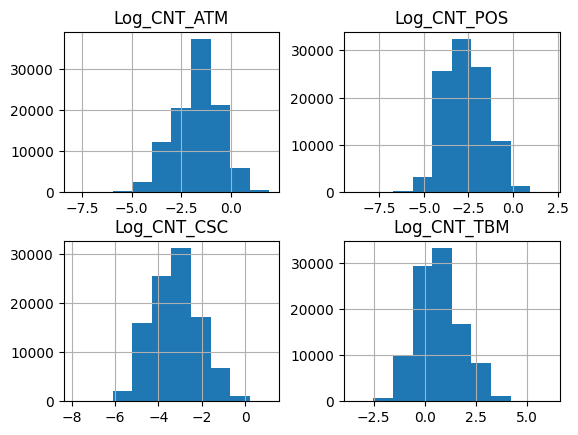

In [14]:
# Plot histogram
profile.hist(column =['Log_CNT_ATM','Log_CNT_POS','Log_CNT_CSC','Log_CNT_TBM'])
plt.show()

Now, you would observe that the distributions are more symmetrical. You can also check the skewness using skew(). 

#### Check the skewness of the 4 transformed variables

In [15]:
profile_2['Log_CNT_ATM','Log_CNT_POS','Log_CNT_CSC','Log_CNT_TBM'].skew()

KeyError: ('Log_CNT_ATM', 'Log_CNT_POS', 'Log_CNT_CSC', 'Log_CNT_TBM')

#### Create a dataframe with only 4 transformed variables. 

### Standardize the variables

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
# create a StandardScaler object
scaler = StandardScaler()

# standardize data by calling the fit_transform() function 


In [14]:
# Create a data frame using standardized data



## 3. Generate K-graph (Elbow curve) to find appropriate number of clusters

In [15]:
from sklearn.cluster import KMeans

#### Create a k-graph (Elbow Curve) using k=1 to 10. 

Use random_state = 99. 

In [16]:
# Put your code to collect the SSE values from k = 1 to 10



In [17]:
# Plot the elbow curve (k-graph)



##  4. Perform k-means clustering (using K=5)

For ease of discussion, perform k-means clustering using K=5 for further analysis. 

Use random_state = 99. 

In [18]:
# Your code here for running k-means for K=5



Attributes of the kmeans object 
cluster_centers_ 


labels_ :
Labels of each point

inertia_ : float
Sum of squared distances of samples to their closest cluster center.

n_iter_ : int
Number of iterations run.

## 5. Analyse the clustering solution and profile the clusters 

### Check Solution Convergence

In [19]:
# Your code here


### Profile the clusters

#### Check the cluster centroids.

In [20]:
# Your code here


#### Create a DataFrame using the cluster centroid for ease of reading

In [21]:
# Your code here


<b>Use the cluster centroids to match the profiles to the clusters.</b>

1. `Transitionals` - This segment customers had a higher than average use of traditional banking methods but were close to the distribution centers on the other transaction categories. The customers seem to be transitioning from brick-and-mortar to other usage patterns.

2. `Service` - This segment had a higher than average rate of customer service contacts and point-of-sale transactions. 

3. `Brick-and-Mortar` - This segment customers had a significantly higher than average use of traditional banking methods and lower than average use of all other transaction categories.

4. `Cashless` - This segment was characterized by a high prevalence of point-of-sale transactions and few traditional bank methods. 

5. `ATMs` - This segment customers eschewed traditional banking methods in favor of ATMs. 

### Evaluate if Clusters Formed is Balanced

#### Add the cluster labels to the ORIGINAL dataframe 'profile'.

In [22]:
# Your code here



#### Count the cluster sizes

In [23]:
#calculating cluster sizes


### Variance explained by the clustering solution

#### Use between_SS or (between_ss/TSS)%

In [24]:
# Your code here
